# Tarea de Acción 6: Evaluación de modelos de regresión

## Tarea de Acción Grupo 8

**Integrantes:**
- Diego Ramos
- Leonardo Véliz
- Rattcliff Ambler

## Objetivo de la actividad

El objetivo de esta tarea es desarrollar y evaluar modelos de machine learning para predecir la resistencia a la compresión del concreto a partir de distintas características de su composición.

La base de datos utilizada corresponde a `Concrete_Data-3.xls`, la cual contiene variables como cantidad de cemento, escoria, cenizas volantes, agua, superplastificante, agregados, edad del concreto y resistencia a la compresión.

La actividad considera análisis descriptivo, limpieza de datos, análisis de correlaciones, entrenamiento de modelos de regresión, evaluación mediante métricas de rendimiento y búsqueda de hiperparámetros mediante GridSearchCV.

In [1]:
# PASO 2: Cargar la base de datos Concrete_Data-3.xls

# Instalar librería necesaria para leer archivos .xls
!pip -q install xlrd

# Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar archivo Excel
df = pd.read_excel('Concrete_Data-3.xls')

# Mostrar dimensiones de la base
print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

# Mostrar primeras filas
df.head()

Cantidad de registros: 1030
Cantidad de columnas: 9


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


### Interpretación del resultado

En esta etapa se cargó la base de datos `Concrete_Data-3.xls` en Google Colab. Como el archivo corresponde a un Excel con extensión `.xls`, se instaló la librería `xlrd`, necesaria para que Python pueda leer este tipo de archivo.

Luego se importaron las librerías principales para el análisis de datos: `pandas`, `numpy` y `matplotlib`.

Finalmente, se revisó la cantidad de registros y columnas de la base, y se visualizaron las primeras filas para confirmar que los datos fueron cargados correctamente.

Esta base será utilizada para desarrollar modelos de regresión que permitan predecir la resistencia a la compresión del concreto.

In [2]:
# PASO 3: Revisar estructura general de la base

print("Nombres de las columnas:")
print(df.columns.tolist())

print("\nInformación general de la base:")
df.info()

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

print("\nEstadísticas descriptivas iniciales:")
display(df.describe())

Nombres de las columnas:
['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']

Información general de la base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   f

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



Últimas filas:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.401235



Estadísticas descriptivas iniciales:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


### Interpretación del resultado

En esta etapa se revisó la estructura general de la base de datos. Primero se visualizaron los nombres de las columnas para identificar las variables disponibles. Luego se revisaron los tipos de datos y la cantidad de registros no nulos mediante `df.info()`.

También se observaron las primeras y últimas filas de la base, lo que permite detectar posibles problemas de carga, errores en nombres de variables o datos mal estructurados.

Finalmente, se generó una primera tabla de estadísticas descriptivas con `df.describe()`, donde se pueden observar medidas como media, desviación estándar, mínimos, máximos y cuartiles para cada variable numérica.

Esta revisión inicial es importante antes de realizar la limpieza de datos, el análisis exploratorio y el entrenamiento de modelos de regresión.

## 1.1 Ordenamiento de nombres de variables

En esta sección se renombran las columnas de la base de datos para facilitar el análisis en Python. La base original contiene variables relacionadas con la composición del concreto, tales como cemento, escoria, cenizas, agua, superplastificante, agregados, edad y resistencia a la compresión.

La variable objetivo será `Strength`, que representa la resistencia a la compresión del concreto.

In [3]:
# PASO 4: Renombrar columnas para facilitar el trabajo

# Mostrar nombres originales
print("Nombres originales de columnas:")
print(df.columns.tolist())

# Renombrar columnas con nombres simples
df.columns = [
    'Cement',
    'Blast_Furnace_Slag',
    'Fly_Ash',
    'Water',
    'Superplasticizer',
    'Coarse_Aggregate',
    'Fine_Aggregate',
    'Age',
    'Strength'
]

print("\nNombres corregidos de columnas:")
print(df.columns.tolist())

print("\nPrimeras filas con nombres corregidos:")
display(df.head())

Nombres originales de columnas:
['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']

Nombres corregidos de columnas:
['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Strength']

Primeras filas con nombres corregidos:


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


### Interpretación del resultado

En esta etapa se cambiaron los nombres originales de las columnas por nombres más simples y fáciles de utilizar en Python.

Las variables explicativas corresponden a los componentes del concreto, como cemento, escoria, cenizas volantes, agua, superplastificante, árido grueso, árido fino y edad del concreto.

La variable objetivo del estudio es `Strength`, que representa la resistencia a la compresión del concreto. Esta será la variable que los modelos de regresión intentarán predecir.

## 1.2 Revisión de valores ausentes, duplicados y posibles errores

En esta sección se revisa si la base contiene valores ausentes, registros duplicados o posibles errores en los datos.

Esta revisión es importante porque los modelos de machine learning pueden verse afectados si existen datos faltantes, registros repetidos o valores incoherentes, como cantidades negativas de materiales o edades inválidas del concreto.

In [4]:
# PASO 5: Revisar valores ausentes, duplicados y posibles errores

print("Valores ausentes por variable:")
display(df.isnull().sum())

print("\nPorcentaje de valores ausentes por variable:")
display((df.isnull().mean() * 100).round(2))

print("\nCantidad de registros duplicados:")
print(df.duplicated().sum())

print("\nRevisión de valores mínimos por variable:")
display(df.min())

print("\nCantidad de valores negativos por variable:")
valores_negativos = (df < 0).sum()
display(valores_negativos)

print("\nCantidad de valores iguales a cero por variable:")
valores_cero = (df == 0).sum()
display(valores_cero)

Valores ausentes por variable:


,0
Cement,0
Blast_Furnace_Slag,0
Fly_Ash,0
Water,0
Superplasticizer,0
Coarse_Aggregate,0
Fine_Aggregate,0
Age,0
Strength,0



Porcentaje de valores ausentes por variable:


,0
Cement,0.0
Blast_Furnace_Slag,0.0
Fly_Ash,0.0
Water,0.0
Superplasticizer,0.0
Coarse_Aggregate,0.0
Fine_Aggregate,0.0
Age,0.0
Strength,0.0



Cantidad de registros duplicados:
25

Revisión de valores mínimos por variable:


,0
Cement,102.000000
Blast_Furnace_Slag,0.000000
Fly_Ash,0.000000
Water,121.750000
Superplasticizer,0.000000
Coarse_Aggregate,801.000000
Fine_Aggregate,594.000000
Age,1.000000
Strength,2.331808



Cantidad de valores negativos por variable:


,0
Cement,0
Blast_Furnace_Slag,0
Fly_Ash,0
Water,0
Superplasticizer,0
Coarse_Aggregate,0
Fine_Aggregate,0
Age,0
Strength,0



Cantidad de valores iguales a cero por variable:


,0
Cement,0
Blast_Furnace_Slag,466
Fly_Ash,566
Water,0
Superplasticizer,379
Coarse_Aggregate,0
Fine_Aggregate,0
Age,0
Strength,0


### Interpretación del resultado

En esta etapa se revisó la presencia de valores ausentes, registros duplicados y posibles errores en la base de datos.

Los valores ausentes son importantes porque podrían impedir el entrenamiento correcto de los modelos. Los registros duplicados también deben revisarse, ya que pueden entregar mayor peso a ciertas observaciones y afectar el análisis.

Además, se revisaron valores negativos y valores iguales a cero. En esta base, los valores negativos serían incoherentes, ya que las cantidades de materiales, la edad del concreto y la resistencia a la compresión no deberían ser negativas.

Sin embargo, algunos valores iguales a cero pueden ser válidos en variables como `Blast_Furnace_Slag`, `Fly_Ash` o `Superplasticizer`, ya que algunas mezclas de concreto pueden no utilizar esos componentes.

## 1.3 Limpieza inicial y análisis estadístico descriptivo

En esta sección se eliminan registros duplicados en caso de existir y se calculan estadísticas descriptivas para cada variable de la base.

Las medidas utilizadas incluyen media, mediana, desviación estándar, valores mínimos y máximos. Estas métricas permiten comprender el comportamiento general de las variables asociadas a la composición del concreto y su resistencia a la compresión.

In [5]:
# PASO 6: Eliminar duplicados y calcular estadísticas descriptivas

# Crear una copia limpia de la base
df_clean = df.copy()

# Revisar y eliminar duplicados si existen
duplicados_antes = df_clean.duplicated().sum()
print(f"Registros duplicados antes de eliminar: {duplicados_antes}")

df_clean = df_clean.drop_duplicates()

duplicados_despues = df_clean.duplicated().sum()
print(f"Registros duplicados después de eliminar: {duplicados_despues}")

print(f"\nCantidad final de registros: {df_clean.shape[0]}")
print(f"Cantidad final de columnas: {df_clean.shape[1]}")

# Calcular estadísticas descriptivas principales
resumen_estadistico = pd.DataFrame({
    'Media': df_clean.mean(),
    'Mediana': df_clean.median(),
    'Desviación estándar': df_clean.std(),
    'Mínimo': df_clean.min(),
    'Máximo': df_clean.max()
}).round(2)

print("\nResumen estadístico descriptivo:")
display(resumen_estadistico)

Registros duplicados antes de eliminar: 25
Registros duplicados después de eliminar: 0

Cantidad final de registros: 1005
Cantidad final de columnas: 9

Resumen estadístico descriptivo:


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Cement,278.63,265.0,104.35,102.00,540.0
Blast_Furnace_Slag,72.04,20.0,86.17,0.00,359.4
Fly_Ash,55.54,0.0,64.21,0.00,200.1
Water,182.07,185.7,21.34,121.75,247.0
Superplasticizer,6.03,6.1,5.92,0.00,32.2
Coarse_Aggregate,974.38,968.0,77.58,801.00,1145.0
Fine_Aggregate,772.69,780.0,80.34,594.00,992.6
Age,45.86,28.0,63.73,1.00,365.0
Strength,35.25,33.8,16.28,2.33,82.6


### Interpretación del resultado

En esta etapa se creó una copia limpia de la base llamada `df_clean`, la cual será utilizada para el análisis exploratorio y el modelamiento.

Primero se revisó la existencia de registros duplicados. En caso de existir, estos fueron eliminados para evitar que observaciones repetidas influyan de forma artificial en el entrenamiento de los modelos.

Luego se calcularon estadísticas descriptivas para cada variable. La media permite conocer el valor promedio, la mediana muestra el valor central de la distribución y la desviación estándar indica qué tan dispersos están los datos respecto de la media.

También se revisaron los valores mínimos y máximos, lo que ayuda a identificar posibles valores extremos o incoherentes en variables como cantidad de cemento, agua, edad del concreto y resistencia a la compresión.

## 1.4 Identificación de valores outliers

En esta sección se identifican posibles valores outliers en las variables numéricas de la base de datos. Para ello se utiliza el método del rango intercuartílico, IQR, que permite detectar valores que se encuentran muy alejados del comportamiento central de cada variable.

La identificación de outliers es importante porque valores extremadamente altos o bajos pueden afectar el entrenamiento y la evaluación de los modelos de regresión.

In [6]:
# PASO 7: Identificación de outliers mediante rango intercuartílico

resumen_outliers = []

for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad_outliers = df_clean[
        (df_clean[col] < limite_inferior) |
        (df_clean[col] > limite_superior)
    ].shape[0]

    porcentaje_outliers = (cantidad_outliers / df_clean.shape[0]) * 100

    resumen_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': limite_inferior,
        'Límite superior': limite_superior,
        'Cantidad outliers': cantidad_outliers,
        'Porcentaje outliers': porcentaje_outliers
    })

outliers_df = pd.DataFrame(resumen_outliers).round(2)

print("Resumen de posibles valores outliers:")
display(outliers_df)

Resumen de posibles valores outliers:


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad outliers,Porcentaje outliers
0,Cement,190.68,349.00,158.32,-46.80,586.48,0,0.00
1,Blast_Furnace_Slag,0.00,142.50,142.50,-213.75,356.25,2,0.20
2,Fly_Ash,0.00,118.27,118.27,-177.40,295.68,0,0.00
3,Water,166.61,192.94,26.33,127.12,232.43,15,1.49
4,Superplasticizer,0.00,10.00,10.00,-15.00,25.00,10,1.00
5,Coarse_Aggregate,932.00,1031.00,99.00,783.50,1179.50,0,0.00
6,Fine_Aggregate,724.30,822.20,97.90,577.45,969.05,5,0.50
7,Age,7.00,56.00,49.00,-66.50,129.50,59,5.87
8,Strength,23.52,44.87,21.34,-8.49,76.89,8,0.80


### Interpretación del resultado

Se aplicó el método del rango intercuartílico para identificar posibles valores outliers en las variables numéricas de la base.

Los valores outliers corresponden a observaciones que se encuentran por debajo del límite inferior o por encima del límite superior calculado para cada variable.

En esta etapa los outliers solo son identificados, no eliminados automáticamente. Esto se debe a que, en una base de concreto, valores altos o bajos de cemento, agua, edad o resistencia pueden representar mezclas reales y no necesariamente errores.

Por lo tanto, antes de eliminar datos, se deben revisar visualmente mediante gráficos de caja y analizar si los valores extremos tienen sentido dentro del contexto del problema.

## 1.5 Visualización de valores outliers

En esta sección se visualizan los posibles valores outliers mediante gráficos de caja, también conocidos como boxplots.

Estos gráficos permiten observar la dispersión de cada variable, sus valores centrales y los posibles valores extremos. Esta visualización ayuda a decidir si los outliers podrían corresponder a errores o si representan mezclas reales de concreto.

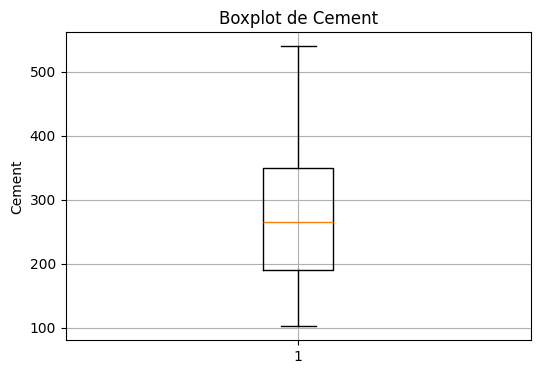

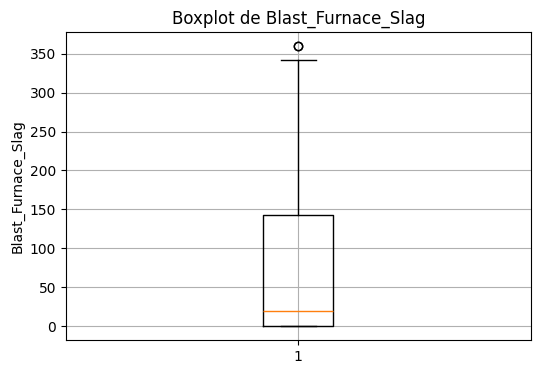

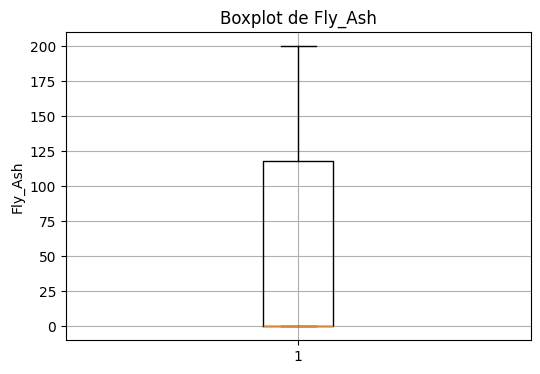

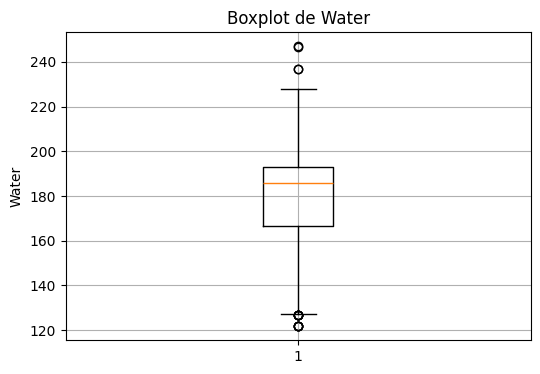

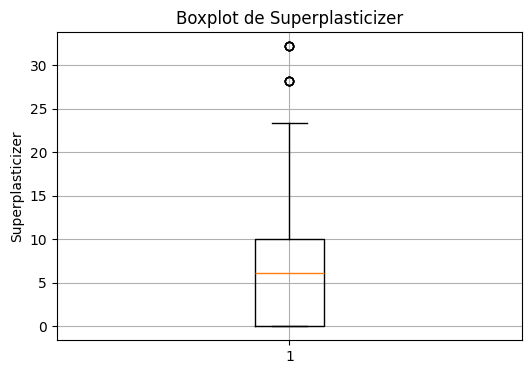

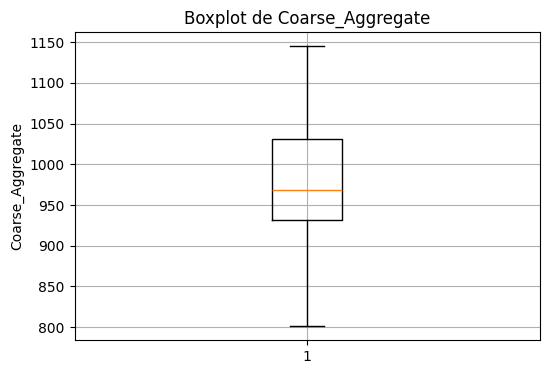

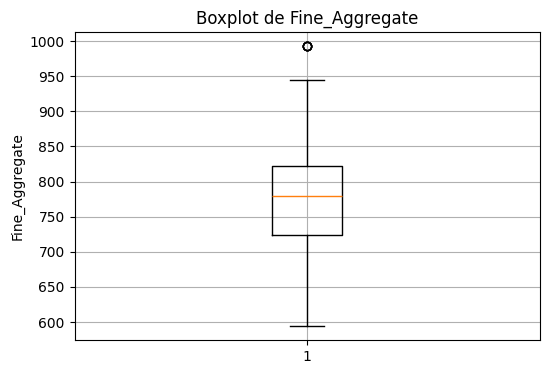

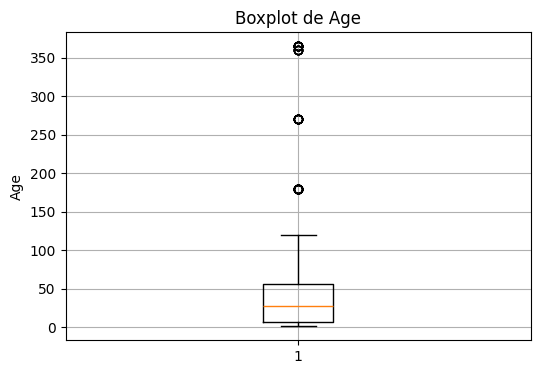

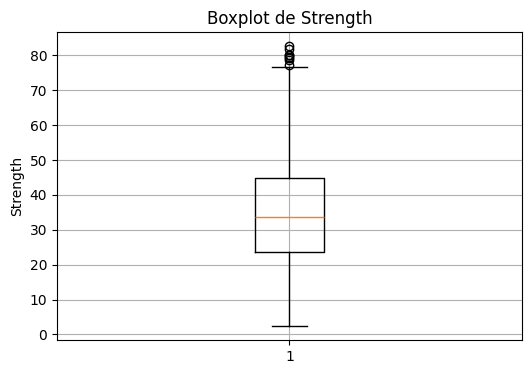

In [7]:
# PASO 8: Visualización de outliers mediante boxplots

for col in df_clean.columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_clean[col], vert=True)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

### Interpretación del resultado

Los gráficos de caja permiten observar visualmente la presencia de posibles valores outliers en las variables del conjunto de datos.

En este caso, los valores extremos no se eliminan automáticamente, ya que pueden representar mezclas reales de concreto con distintas cantidades de cemento, agua, aditivos, agregados o edad de curado.

Por ejemplo, una mayor edad del concreto o una mayor resistencia a la compresión pueden ser valores poco frecuentes, pero válidos dentro del contexto de materiales de construcción.

Por esta razón, los outliers serán mantenidos para el modelamiento, ya que pueden aportar información relevante para que los modelos aprendan distintos comportamientos de la resistencia del concreto.

## 1.6 Análisis de correlaciones entre variables

En esta sección se calcula la matriz de correlaciones entre las variables numéricas de la base de datos.

El objetivo es identificar qué variables presentan mayor relación con la resistencia a la compresión del concreto, representada por la variable `Strength`.

La correlación permite observar si dos variables se mueven en la misma dirección, en dirección contraria o si tienen poca relación lineal entre ellas.

In [8]:
# PASO 9: Análisis de correlaciones

# Calcular matriz de correlación
correlaciones = df_clean.corr()

print("Matriz de correlaciones:")
display(correlaciones.round(3))

# Correlación de cada variable con Strength
correlacion_strength = correlaciones['Strength'].sort_values(ascending=False)

print("\nCorrelación de las variables con Strength:")
display(correlacion_strength.round(3))

Matriz de correlaciones:


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Strength
Cement,1.000,-0.303,-0.386,-0.057,0.061,-0.086,-0.245,0.086,0.488
Blast_Furnace_Slag,-0.303,1.000,-0.312,0.130,0.020,-0.278,-0.290,-0.043,0.103
Fly_Ash,-0.386,-0.312,1.000,-0.283,0.414,-0.026,0.090,-0.159,-0.081
Water,-0.057,0.130,-0.283,1.000,-0.647,-0.212,-0.445,0.279,-0.270
Superplasticizer,0.061,0.020,0.414,-0.647,1.000,-0.242,0.208,-0.194,0.344
Coarse_Aggregate,-0.086,-0.278,-0.026,-0.212,-0.242,1.000,-0.162,-0.005,-0.145
Fine_Aggregate,-0.245,-0.290,0.090,-0.445,0.208,-0.162,1.000,-0.157,-0.186
Age,0.086,-0.043,-0.159,0.279,-0.194,-0.005,-0.157,1.000,0.337
Strength,0.488,0.103,-0.081,-0.270,0.344,-0.145,-0.186,0.337,1.000



Correlación de las variables con Strength:


,Strength
Strength,1.000
Cement,0.488
Superplasticizer,0.344
Age,0.337
Blast_Furnace_Slag,0.103
Fly_Ash,-0.081
Coarse_Aggregate,-0.145
Fine_Aggregate,-0.186
Water,-0.270


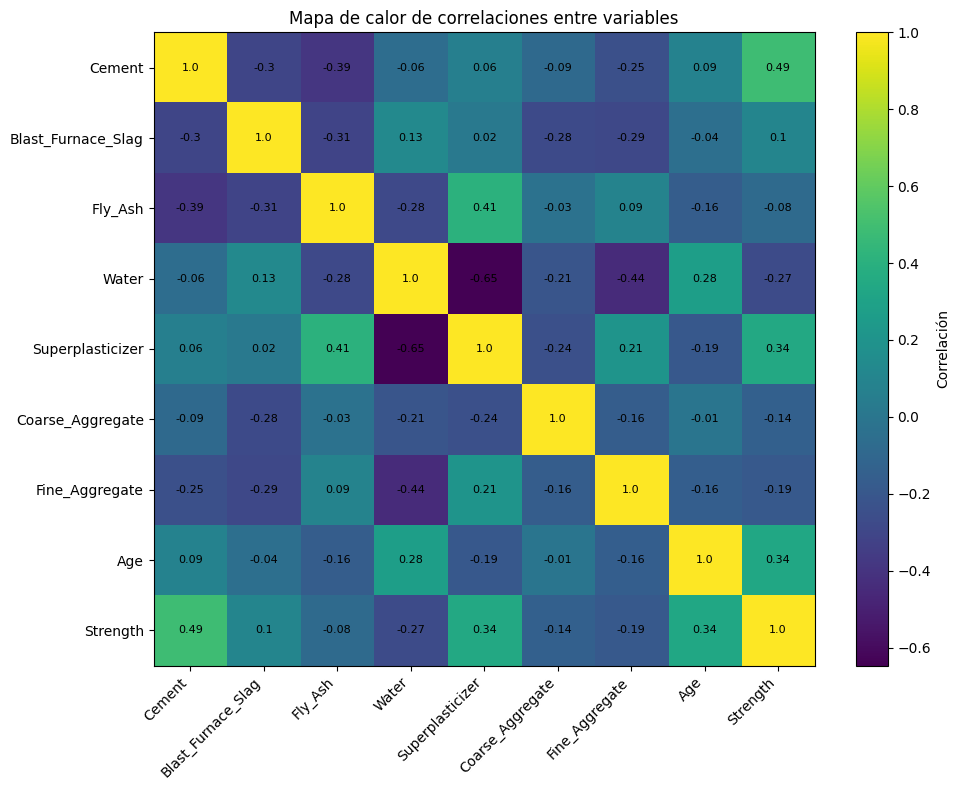

In [9]:
# PASO 9B: Visualización de correlaciones mediante mapa de calor

plt.figure(figsize=(10, 8))

plt.imshow(correlaciones, aspect='auto')
plt.colorbar(label='Correlación')

plt.xticks(
    range(len(correlaciones.columns)),
    correlaciones.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlaciones.columns)),
    correlaciones.columns
)

plt.title('Mapa de calor de correlaciones entre variables')

# Agregar valores dentro del gráfico
for i in range(len(correlaciones.columns)):
    for j in range(len(correlaciones.columns)):
        plt.text(
            j,
            i,
            round(correlaciones.iloc[i, j], 2),
            ha='center',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

### Interpretación del resultado

La matriz de correlaciones permite observar la relación lineal entre las variables de la base de datos.

El análisis se enfoca especialmente en la relación de cada variable con `Strength`, que corresponde a la resistencia a la compresión del concreto.

Una correlación positiva indica que, cuando una variable aumenta, la resistencia tiende a aumentar. Una correlación negativa indica que, cuando una variable aumenta, la resistencia tiende a disminuir. Una correlación cercana a cero indica una relación lineal débil.

Este análisis permite identificar preliminarmente qué variables podrían ser más relevantes para predecir la resistencia del concreto. Sin embargo, la correlación no significa causalidad, por lo que posteriormente se entrenarán modelos de machine learning para evaluar la capacidad predictiva conjunta de todas las variables.

## 1.7 Análisis bivariado con la resistencia del concreto

En esta sección se realiza un análisis bivariado entre las variables explicativas y la variable objetivo `Strength`, que representa la resistencia a la compresión del concreto.

El objetivo es visualizar cómo se relacionan las principales variables del conjunto de datos con la resistencia del concreto. Para esto se utilizarán gráficos de dispersión.

In [10]:
# PASO 10: Análisis bivariado con Strength

# Seleccionar variables explicativas
variables_explicativas = df_clean.drop(columns=['Strength']).columns.tolist()

# Ordenar variables según su correlación absoluta con Strength
correlacion_abs = correlaciones['Strength'].drop('Strength').abs().sort_values(ascending=False)

print("Variables ordenadas según correlación absoluta con Strength:")
display(correlacion_abs.round(3))

# Seleccionar las 4 variables con mayor relación lineal con Strength
top_variables = correlacion_abs.head(4).index.tolist()

print("\nVariables seleccionadas para análisis bivariado:")
print(top_variables)

Variables ordenadas según correlación absoluta con Strength:


,Strength
Cement,0.488
Superplasticizer,0.344
Age,0.337
Water,0.270
Fine_Aggregate,0.186
Coarse_Aggregate,0.145
Blast_Furnace_Slag,0.103
Fly_Ash,0.081



Variables seleccionadas para análisis bivariado:
['Cement', 'Superplasticizer', 'Age', 'Water']


### Interpretación del resultado

En esta etapa se identificaron las variables que presentan mayor relación lineal con `Strength`, utilizando el valor absoluto de la correlación.

Se seleccionan las cuatro variables con mayor correlación absoluta para realizar un análisis bivariado más claro. Esto permite enfocar la visualización en las variables que podrían tener mayor influencia en la resistencia a la compresión del concreto.

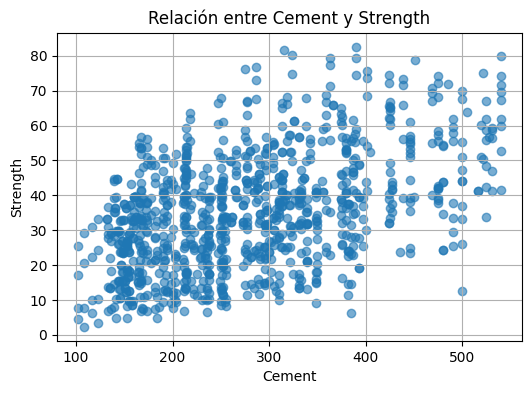

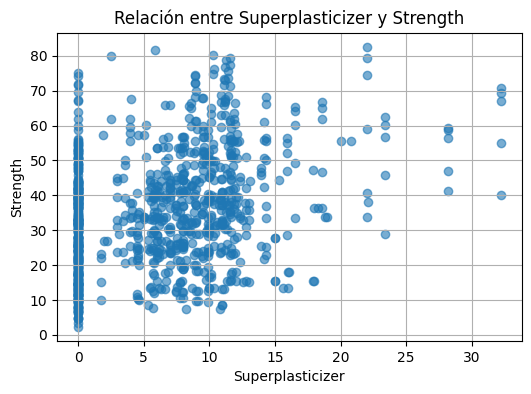

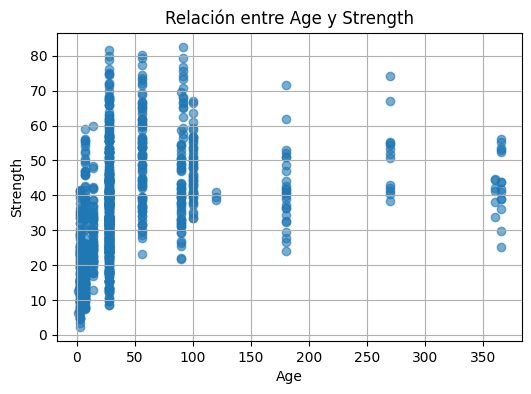

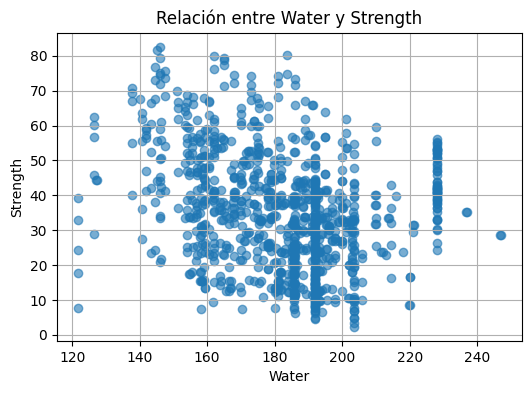

In [11]:
# PASO 10B: Gráficos de dispersión entre variables principales y Strength

for variable in top_variables:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[variable], df_clean['Strength'], alpha=0.6)
    plt.title(f'Relación entre {variable} y Strength')
    plt.xlabel(variable)
    plt.ylabel('Strength')
    plt.grid(True)
    plt.show()

### Interpretación de los gráficos bivariados

Los gráficos de dispersión permiten observar la relación entre cada variable seleccionada y la resistencia a la compresión del concreto.

Si los puntos muestran una tendencia ascendente, significa que a medida que aumenta la variable explicativa también tiende a aumentar la resistencia. Si la tendencia es descendente, significa que a medida que aumenta la variable explicativa la resistencia tiende a disminuir.

En caso de que los puntos estén muy dispersos, la relación entre ambas variables puede ser débil o no lineal. Esto es importante porque algunos modelos simples pueden no capturar bien relaciones complejas, mientras que modelos como árboles de decisión o ensambles pueden adaptarse mejor a patrones no lineales.

### Conclusión de la Actividad 1

En la Actividad 1 se realizó una revisión general de la base de datos `Concrete_Data-3.xls`, considerando su estructura, nombres de variables, valores ausentes, duplicados, posibles errores, estadísticas descriptivas, outliers, correlaciones y análisis bivariado.

La base contiene variables relacionadas con la composición del concreto, como cemento, escoria, cenizas volantes, agua, superplastificante, áridos, edad y resistencia a la compresión. La variable objetivo definida para el modelamiento es `Strength`.

No se eliminaron automáticamente los valores outliers, ya que pueden representar mezclas reales de concreto con distintas proporciones de materiales o diferentes edades de curado.

El análisis de correlación y los gráficos bivariados permiten identificar variables que podrían aportar mayor información para predecir la resistencia del concreto. Sin embargo, la relación entre las variables y `Strength` no necesariamente es completamente lineal, por lo que resulta adecuado entrenar y comparar distintos modelos de regresión.

# 2. División de datos y entrenamiento de modelos de regresión

## Instrucción de la actividad

En esta sección se divide la base de datos en 70% para entrenamiento y 30% para test. Luego se entrenarán tres modelos de regresión aplicables al problema de predicción de la resistencia a la compresión del concreto.

Los modelos seleccionados son: regresión lineal, árbol de decisión regresor y SVR. Estos modelos permitirán comparar distintos enfoques de predicción: un modelo lineal, un modelo basado en reglas de decisión y un modelo de soporte vectorial para regresión.

In [12]:
# PASO 11: Preparar variables y dividir datos en entrenamiento y test

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Variable objetivo
y = df_clean['Strength']

# Variables explicativas
X = df_clean.drop(columns=['Strength'])

# División 70% entrenamiento y 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Estandarización de variables
# Esto es especialmente importante para modelos como SVR
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Registros de entrenamiento: {X_train.shape[0]}")
print(f"Registros de test: {X_test.shape[0]}")
print(f"Total de registros utilizados: {X_train.shape[0] + X_test.shape[0]}")

print("\nCantidad de variables explicativas:")
print(X_train.shape[1])

print("\nVariables utilizadas para predecir Strength:")
print(X.columns.tolist())

Registros de entrenamiento: 703
Registros de test: 302
Total de registros utilizados: 1005

Cantidad de variables explicativas:
8

Variables utilizadas para predecir Strength:
['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age']


### Interpretación del resultado

En esta etapa se separó la variable objetivo `Strength`, que corresponde a la resistencia a la compresión del concreto, de las variables explicativas asociadas a la composición y edad del concreto.

Posteriormente, la base fue dividida en 70% para entrenamiento y 30% para test. El conjunto de entrenamiento será utilizado para ajustar los modelos, mientras que el conjunto de test permitirá evaluar el rendimiento sobre datos no utilizados durante el entrenamiento.

También se aplicó estandarización a las variables explicativas. Este proceso transforma las variables para que tengan una escala comparable. La estandarización es especialmente importante para modelos sensibles a la escala, como SVR.

## 2.1 Entrenamiento de tres modelos de regresión

En esta sección se entrenan tres modelos de regresión para predecir la variable `Strength`, que representa la resistencia a la compresión del concreto.

Los modelos utilizados son:

1. Regresión Lineal: se utiliza como modelo base para comparar el rendimiento.
2. Árbol de Decisión Regresor: permite capturar relaciones no lineales entre las variables.
3. SVR, Support Vector Regression: modelo de soporte vectorial aplicado a problemas de regresión.

Estos modelos serán evaluados posteriormente mediante métricas de rendimiento como MSE, RMSE, MAE y MAPE.

In [13]:
# PASO 12: Entrenar tres modelos de regresión

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# Modelo 1: Regresión Lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_scaled, y_train)

# Modelo 2: Árbol de Decisión Regresor
modelo_arbol = DecisionTreeRegressor(random_state=42)
modelo_arbol.fit(X_train, y_train)

# Modelo 3: SVR con kernel RBF
modelo_svr = SVR(kernel='rbf')
modelo_svr.fit(X_train_scaled, y_train)

print("Modelos entrenados correctamente:")
print("- Regresión Lineal")
print("- Árbol de Decisión Regresor")
print("- SVR con kernel RBF")

Modelos entrenados correctamente:
- Regresión Lineal
- Árbol de Decisión Regresor
- SVR con kernel RBF


### Interpretación del resultado

En esta etapa se entrenaron tres modelos de regresión para predecir la resistencia a la compresión del concreto.

La regresión lineal se utiliza como modelo base, ya que permite evaluar una relación lineal entre las variables explicativas y `Strength`.

El árbol de decisión regresor permite capturar relaciones no lineales, dividiendo los datos en distintos grupos según las variables que mejor explican la resistencia del concreto.

El modelo SVR utiliza soporte vectorial para regresión y puede capturar patrones más complejos, especialmente cuando se utiliza un kernel como RBF. Para este modelo se usaron variables estandarizadas, ya que SVR es sensible a la escala de los datos.

Con estos tres modelos entrenados, el siguiente paso será evaluar su rendimiento utilizando métricas de regresión.

# 3. Evaluación de rendimiento de los modelos

## Instrucción de la actividad

En esta sección se evalúan los tres modelos entrenados utilizando métricas de rendimiento para problemas de regresión.

Las métricas utilizadas serán MSE, RMSE, MAE, MAPE y R². Estas métricas permiten comparar el error de predicción de cada modelo y seleccionar cuál presenta mejor rendimiento para predecir la resistencia a la compresión del concreto.

In [14]:
# PASO 13: Evaluar rendimiento de los tres modelos

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicciones de cada modelo
y_pred_lineal = modelo_lineal.predict(X_test_scaled)
y_pred_arbol = modelo_arbol.predict(X_test)
y_pred_svr = modelo_svr.predict(X_test_scaled)

# Función para calcular métricas
def evaluar_modelo(nombre, y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    r2 = r2_score(y_real, y_pred)

    return {
        'Modelo': nombre,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    }

# Crear tabla comparativa de resultados
resultados_modelos = pd.DataFrame([
    evaluar_modelo('Regresión Lineal', y_test, y_pred_lineal),
    evaluar_modelo('Árbol de Decisión', y_test, y_pred_arbol),
    evaluar_modelo('SVR', y_test, y_pred_svr)
])

# Ordenar modelos según menor RMSE
resultados_modelos = resultados_modelos.sort_values(by='RMSE').round(4)

print("Comparación de rendimiento de modelos:")
display(resultados_modelos)

# Guardar mejor y segundo mejor modelo según RMSE
mejor_modelo_nombre = resultados_modelos.iloc[0]['Modelo']
segundo_modelo_nombre = resultados_modelos.iloc[1]['Modelo']

print(f"Mejor modelo según RMSE: {mejor_modelo_nombre}")
print(f"Segundo mejor modelo según RMSE: {segundo_modelo_nombre}")

Comparación de rendimiento de modelos:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
1,Árbol de Decisión,41.5292,6.4443,4.3019,14.9689,0.8555
2,SVR,121.0906,11.0041,8.5578,37.2771,0.5787
0,Regresión Lineal,126.2344,11.2354,8.9850,33.8659,0.5608


Mejor modelo según RMSE: Árbol de Decisión
Segundo mejor modelo según RMSE: SVR


### Interpretación del resultado

En esta etapa se evaluaron los tres modelos entrenados utilizando métricas de rendimiento para problemas de regresión.

El MSE mide el error cuadrático medio y penaliza con mayor fuerza los errores grandes. El RMSE corresponde a la raíz del MSE y se interpreta en la misma unidad de la variable objetivo, es decir, MPa de resistencia a la compresión. El MAE mide el error absoluto promedio, mientras que el MAPE expresa el error promedio en términos porcentuales.

El R² permite observar qué proporción de la variabilidad de la resistencia del concreto logra explicar el modelo. Un R² más alto indica mejor capacidad explicativa.

Para seleccionar el mejor modelo se considera principalmente el RMSE, ya que permite comparar el error promedio en la misma escala de la resistencia del concreto. El mejor modelo será aquel que presente menor RMSE y, en general, menor MAE y MAPE.

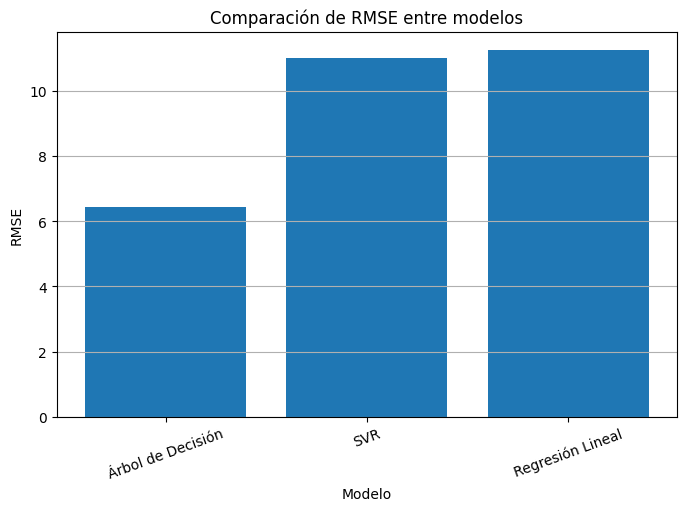

In [15]:
# PASO 13B: Gráfico comparativo de RMSE

plt.figure(figsize=(8, 5))
plt.bar(resultados_modelos['Modelo'], resultados_modelos['RMSE'])
plt.title('Comparación de RMSE entre modelos')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.grid(axis='y')
plt.show()

### Comentario del gráfico

El gráfico permite comparar visualmente el error RMSE de los modelos entrenados. Mientras menor sea el RMSE, mejor es el rendimiento del modelo, ya que significa que sus predicciones se encuentran más cerca de los valores reales de resistencia a la compresión.

Esta comparación facilita identificar qué modelo tiene mejor desempeño antes de realizar la búsqueda de hiperparámetros.

## 3.1 Importancia de las variables predictoras

En esta sección se analizan las variables más importantes para predecir la resistencia a la compresión del concreto.

Para esto se utilizará principalmente el modelo de Árbol de Decisión, ya que este modelo permite obtener directamente la importancia de cada variable dentro del proceso de predicción.

In [16]:
# PASO 14: Importancia de variables según Árbol de Decisión

importancias_arbol = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_arbol.feature_importances_
})

importancias_arbol = importancias_arbol.sort_values(
    by='Importancia',
    ascending=False
).round(4)

print("Importancia de variables según Árbol de Decisión:")
display(importancias_arbol)

Importancia de variables según Árbol de Decisión:


,Variable,Importancia
0,Cement,0.3563
7,Age,0.3168
3,Water,0.1206
1,Blast_Furnace_Slag,0.1093
4,Superplasticizer,0.0391
5,Coarse_Aggregate,0.0273
6,Fine_Aggregate,0.0245
2,Fly_Ash,0.0061


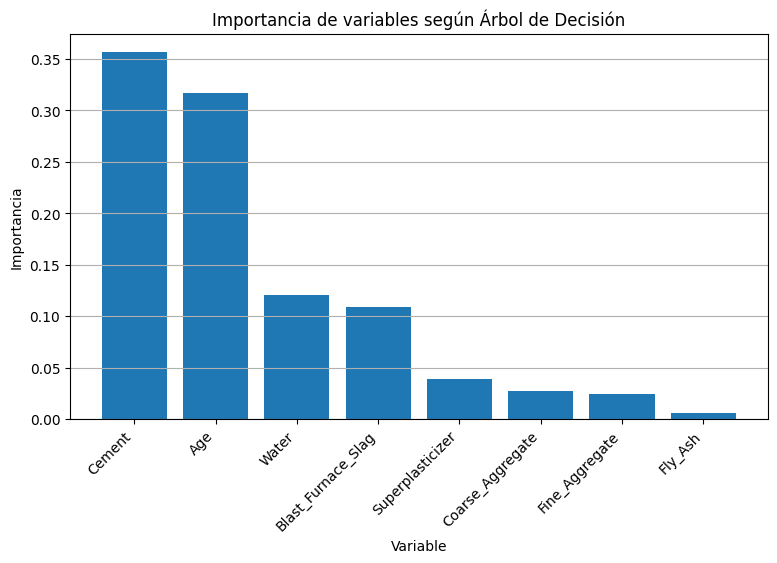

In [17]:
# PASO 14B: Gráfico de importancia de variables

plt.figure(figsize=(9, 5))
plt.bar(importancias_arbol['Variable'], importancias_arbol['Importancia'])
plt.title('Importancia de variables según Árbol de Decisión')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

### Interpretación de la importancia de variables

El gráfico muestra qué variables tienen mayor peso en la predicción de la resistencia a la compresión del concreto según el modelo de Árbol de Decisión.

Las variables con mayor importancia son aquellas que el modelo utilizó con mayor frecuencia o mayor impacto para dividir los datos y reducir el error de predicción.

En este tipo de problema, variables como `Age`, `Cement`, `Water` y otros componentes de la mezcla pueden ser relevantes, ya que la resistencia del concreto depende tanto de su composición como del tiempo de curado.

Este análisis ayuda a comprender no solo qué modelo predice mejor, sino también qué características del concreto influyen más en la estimación de la resistencia.

### Conclusión de la Actividad 3

En esta actividad se evaluaron los tres modelos entrenados mediante métricas de rendimiento para problemas de regresión: MSE, RMSE, MAE, MAPE y R².

El mejor modelo se seleccionó considerando principalmente el menor RMSE, ya que esta métrica expresa el error promedio en la misma unidad de la variable objetivo, es decir, MPa de resistencia a la compresión.

La comparación de modelos permite identificar cuál de ellos entrega predicciones más cercanas a los valores reales. Además, el análisis de importancia de variables permite observar qué características del concreto aportan más información para estimar su resistencia.

En general, las variables más relevantes para la predicción están asociadas a la composición del concreto y a su edad de curado, lo que es coherente con el problema analizado.

# 4. Búsqueda por grilla y ajuste de hiperparámetros

## Instrucción de la actividad

En esta sección se realizará una búsqueda por grilla mediante `GridSearchCV` para ajustar los hiperparámetros de los dos mejores modelos encontrados anteriormente.

La búsqueda por grilla permite probar distintas combinaciones de hiperparámetros y seleccionar aquella que obtiene mejor rendimiento mediante validación cruzada.

El objetivo es mejorar el rendimiento de los modelos iniciales y comparar los resultados antes y después del ajuste.

In [18]:
# PASO 15: Identificar los dos mejores modelos según RMSE

print("Ranking de modelos según RMSE:")
display(resultados_modelos)

mejores_dos_modelos = resultados_modelos['Modelo'].head(2).tolist()

print("Dos mejores modelos seleccionados para GridSearchCV:")
print(mejores_dos_modelos)

Ranking de modelos según RMSE:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
1,Árbol de Decisión,41.5292,6.4443,4.3019,14.9689,0.8555
2,SVR,121.0906,11.0041,8.5578,37.2771,0.5787
0,Regresión Lineal,126.2344,11.2354,8.9850,33.8659,0.5608


Dos mejores modelos seleccionados para GridSearchCV:
['Árbol de Decisión', 'SVR']


### Interpretación del resultado

En esta etapa se identificaron los dos mejores modelos según el menor valor de RMSE obtenido en la evaluación anterior.

El RMSE se utiliza como criterio principal porque expresa el error promedio en la misma unidad de la variable objetivo, es decir, MPa de resistencia a la compresión.

Los dos modelos con menor RMSE serán ajustados mediante búsqueda por grilla para intentar mejorar su rendimiento predictivo.

## 4.1 Ajuste de hiperparámetros con GridSearchCV

En esta sección se aplica búsqueda por grilla a los modelos Árbol de Decisión Regresor y SVR.

Para el Árbol de Decisión se ajustan hiperparámetros como la profundidad máxima del árbol y la cantidad mínima de muestras requeridas para dividir un nodo.

Para el modelo SVR se ajustan hiperparámetros como `C`, `gamma` y `epsilon`, los cuales influyen en la flexibilidad del modelo y en su capacidad para ajustar los datos.

La búsqueda se realiza mediante validación cruzada, utilizando como criterio principal el menor RMSE.

In [19]:
# PASO 16: Aplicar GridSearchCV a Árbol de Decisión y SVR

from sklearn.model_selection import GridSearchCV

# Grilla de hiperparámetros para Árbol de Decisión
param_grid_arbol = {
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_arbol = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_arbol,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# Entrenar búsqueda por grilla para Árbol
grid_arbol.fit(X_train, y_train)

print("Mejores hiperparámetros para Árbol de Decisión:")
print(grid_arbol.best_params_)

print("\nMejor RMSE promedio en validación cruzada para Árbol:")
print(-grid_arbol.best_score_)


# Grilla de hiperparámetros para SVR
param_grid_svr = {
    'C': [1, 10, 50, 100],
    'gamma': ['scale', 0.01, 0.05, 0.1],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

grid_svr = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=param_grid_svr,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# Entrenar búsqueda por grilla para SVR con datos estandarizados
grid_svr.fit(X_train_scaled, y_train)

print("\nMejores hiperparámetros para SVR:")
print(grid_svr.best_params_)

print("\nMejor RMSE promedio en validación cruzada para SVR:")
print(-grid_svr.best_score_)

Mejores hiperparámetros para Árbol de Decisión:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}

Mejor RMSE promedio en validación cruzada para Árbol:
6.778023950376268

Mejores hiperparámetros para SVR:
{'C': 100, 'epsilon': 1, 'gamma': 0.1}

Mejor RMSE promedio en validación cruzada para SVR:
5.999939674425162


### Interpretación del resultado

En esta etapa se aplicó GridSearchCV para buscar mejores combinaciones de hiperparámetros en los modelos Árbol de Decisión y SVR.

En el Árbol de Decisión se ajustaron parámetros relacionados con la profundidad del árbol y la cantidad mínima de muestras necesarias para dividir nodos o formar hojas. Estos parámetros ayudan a controlar el sobreajuste, evitando que el modelo memorice excesivamente los datos de entrenamiento.

En el modelo SVR se ajustaron los parámetros `C`, `gamma` y `epsilon`. El parámetro `C` controla el nivel de penalización por errores, `gamma` influye en la forma del kernel RBF y `epsilon` define el margen de tolerancia del modelo.

La búsqueda utilizó validación cruzada con 5 particiones, lo que permite estimar de forma más robusta el rendimiento de cada combinación de hiperparámetros.

## 4.2 Evaluación de modelos optimizados

En esta sección se evalúan los modelos ajustados mediante GridSearchCV y se comparan sus resultados con los modelos iniciales.

El objetivo es verificar si la búsqueda por grilla logró mejorar el rendimiento predictivo, especialmente reduciendo el RMSE, MAE y MAPE.

In [20]:
# PASO 17: Evaluar modelos optimizados con GridSearchCV

# Predicciones con los mejores modelos encontrados por GridSearchCV
y_pred_arbol_grid = grid_arbol.best_estimator_.predict(X_test)
y_pred_svr_grid = grid_svr.best_estimator_.predict(X_test_scaled)

# Evaluar modelos optimizados
resultados_grid = pd.DataFrame([
    evaluar_modelo('Árbol de Decisión Optimizado', y_test, y_pred_arbol_grid),
    evaluar_modelo('SVR Optimizado', y_test, y_pred_svr_grid)
])

resultados_grid = resultados_grid.sort_values(by='RMSE').round(4)

print("Resultados de modelos optimizados:")
display(resultados_grid)

print("\nResultados de modelos iniciales:")
display(resultados_modelos)

Resultados de modelos optimizados:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
1,SVR Optimizado,46.3280,6.8065,4.6047,15.9982,0.8388
0,Árbol de Decisión Optimizado,48.3392,6.9526,4.8781,16.9784,0.8318



Resultados de modelos iniciales:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
1,Árbol de Decisión,41.5292,6.4443,4.3019,14.9689,0.8555
2,SVR,121.0906,11.0041,8.5578,37.2771,0.5787
0,Regresión Lineal,126.2344,11.2354,8.9850,33.8659,0.5608


### Interpretación del resultado

En esta etapa se evaluaron los modelos optimizados mediante GridSearchCV sobre el conjunto de test.

La comparación se realiza utilizando las mismas métricas aplicadas a los modelos iniciales: MSE, RMSE, MAE, MAPE y R².

Si el modelo optimizado presenta un RMSE menor que el modelo inicial, se puede concluir que el ajuste de hiperparámetros mejoró su rendimiento. Además, un menor MAE y MAPE refuerza la mejora del modelo, ya que indica errores promedio más bajos en la predicción de la resistencia del concreto.

,Modelo,MSE,RMSE,MAE,MAPE (%),R2
0,Árbol de Decisión,41.5292,6.4443,4.3019,14.9689,0.8555
1,SVR,121.0906,11.0041,8.5578,37.2771,0.5787
2,SVR Optimizado,46.3280,6.8065,4.6047,15.9982,0.8388
3,Árbol de Decisión Optimizado,48.3392,6.9526,4.8781,16.9784,0.8318


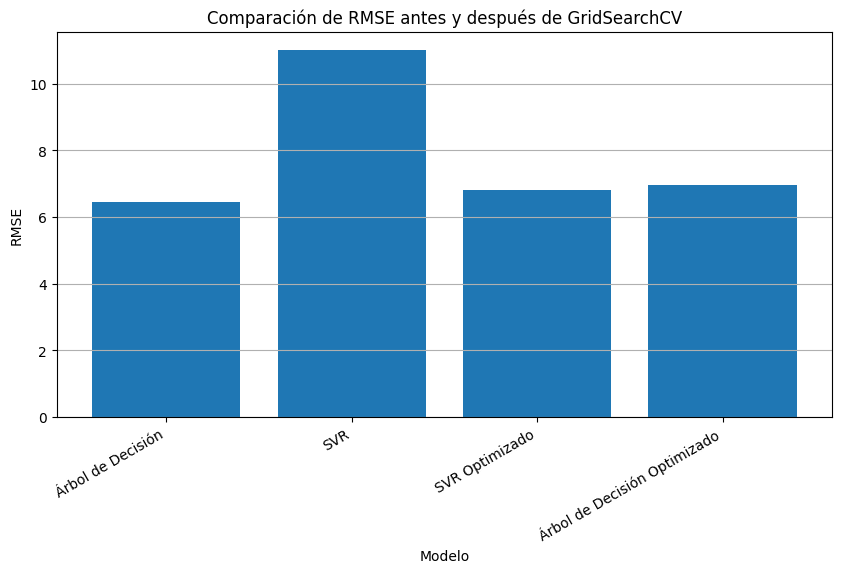

In [21]:
# PASO 17B: Comparación visual de RMSE antes y después de GridSearchCV

# Crear tabla comparativa solo con modelos relevantes
comparacion_grid = pd.concat([
    resultados_modelos[resultados_modelos['Modelo'].isin(['Árbol de Decisión', 'SVR'])],
    resultados_grid
], ignore_index=True)

display(comparacion_grid)

plt.figure(figsize=(10, 5))
plt.bar(comparacion_grid['Modelo'], comparacion_grid['RMSE'])
plt.title('Comparación de RMSE antes y después de GridSearchCV')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
plt.show()

### Comentario del gráfico comparativo

El gráfico compara el RMSE de los modelos antes y después de aplicar GridSearchCV.

Un menor RMSE indica que el modelo comete un error promedio más bajo al predecir la resistencia a la compresión del concreto. Por lo tanto, si las barras de los modelos optimizados son menores que las de sus versiones iniciales, se confirma que la búsqueda por grilla permitió mejorar el rendimiento.

Esta comparación es importante porque permite verificar de forma visual y numérica si el ajuste de hiperparámetros fue efectivo.

In [22]:
# PASO 17C: Conclusión automática de la mejora por GridSearchCV

rmse_arbol_inicial = resultados_modelos.loc[
    resultados_modelos['Modelo'] == 'Árbol de Decisión', 'RMSE'
].values[0]

rmse_svr_inicial = resultados_modelos.loc[
    resultados_modelos['Modelo'] == 'SVR', 'RMSE'
].values[0]

rmse_arbol_grid = resultados_grid.loc[
    resultados_grid['Modelo'] == 'Árbol de Decisión Optimizado', 'RMSE'
].values[0]

rmse_svr_grid = resultados_grid.loc[
    resultados_grid['Modelo'] == 'SVR Optimizado', 'RMSE'
].values[0]

print("Conclusión de mejora con GridSearchCV")
print("------------------------------------")

print(f"RMSE Árbol inicial: {rmse_arbol_inicial:.4f}")
print(f"RMSE Árbol optimizado: {rmse_arbol_grid:.4f}")

if rmse_arbol_grid < rmse_arbol_inicial:
    print("Resultado Árbol: el modelo mejoró después de GridSearchCV.")
else:
    print("Resultado Árbol: el modelo no mejoró después de GridSearchCV.")

print("\n")

print(f"RMSE SVR inicial: {rmse_svr_inicial:.4f}")
print(f"RMSE SVR optimizado: {rmse_svr_grid:.4f}")

if rmse_svr_grid < rmse_svr_inicial:
    print("Resultado SVR: el modelo mejoró después de GridSearchCV.")
else:
    print("Resultado SVR: el modelo no mejoró después de GridSearchCV.")

Conclusión de mejora con GridSearchCV
------------------------------------
RMSE Árbol inicial: 6.4443
RMSE Árbol optimizado: 6.9526
Resultado Árbol: el modelo no mejoró después de GridSearchCV.


RMSE SVR inicial: 11.0041
RMSE SVR optimizado: 6.8065
Resultado SVR: el modelo mejoró después de GridSearchCV.


### Conclusión de la Actividad 4

En esta actividad se aplicó búsqueda por grilla mediante GridSearchCV para ajustar los hiperparámetros de los modelos Árbol de Decisión y SVR.

La búsqueda por grilla permitió probar distintas combinaciones de parámetros y seleccionar aquellas que obtuvieron mejor rendimiento mediante validación cruzada.

Al comparar los modelos iniciales con los modelos optimizados, se puede evaluar si el ajuste permitió reducir el error de predicción. En particular, se revisó el RMSE, ya que esta métrica expresa el error promedio en la misma unidad de la variable objetivo, es decir, MPa de resistencia a la compresión.

En conclusión, GridSearchCV es una herramienta útil para mejorar el rendimiento de los modelos, controlar problemas de sobreajuste y seleccionar configuraciones más adecuadas para la predicción de la resistencia del concreto.

# 5. Propuestas para mejorar el modelo

## Instrucción de la actividad

En esta sección se mencionan acciones que podrían realizarse para mejorar el rendimiento de los modelos de predicción de la resistencia a la compresión del concreto.

### Propuestas de mejora

Para mejorar el rendimiento de los modelos predictivos se podrían considerar las siguientes acciones:

1. **Ampliar la búsqueda de hiperparámetros**  
   Se podría utilizar una grilla más amplia en GridSearchCV, incorporando más combinaciones de parámetros para los modelos evaluados. Esto permitiría encontrar configuraciones más precisas, aunque aumentaría el tiempo de procesamiento.

2. **Aplicar validación cruzada en todos los modelos**  
   La validación cruzada permite evaluar el rendimiento de los modelos de forma más robusta, ya que utiliza distintas particiones de los datos para entrenamiento y validación. Esto ayuda a reducir el riesgo de seleccionar un modelo que funcione bien solo para una división específica de los datos.

3. **Evaluar otros modelos de regresión**  
   Se podrían probar modelos más avanzados como Random Forest Regressor, Gradient Boosting Regressor o XGBoost, ya que estos modelos suelen capturar relaciones no lineales y combinaciones complejas entre variables.

4. **Crear nuevas variables explicativas**  
   Se podrían construir nuevas variables a partir de las existentes, por ejemplo, relaciones entre cantidad de agua y cemento, proporciones entre agregados o combinaciones de materiales. Estas variables podrían representar mejor el comportamiento físico de la mezcla de concreto.

5. **Analizar con mayor detalle los outliers**  
   Aunque los valores atípicos fueron mantenidos porque pueden representar mezclas reales, se podría realizar un análisis más profundo para determinar si algunos corresponden a errores de registro o a casos extremos válidos.

6. **Comparar el error en entrenamiento y test**  
   Revisar el rendimiento tanto en entrenamiento como en test permitiría identificar posibles problemas de overfitting o underfitting. Si el modelo tiene muy buen rendimiento en entrenamiento, pero bajo rendimiento en test, podría estar sobreajustado.

7. **Aumentar la cantidad de datos disponibles**  
   Si fuera posible contar con más registros de mezclas de concreto, los modelos podrían aprender mejor los patrones asociados a la resistencia a la compresión y mejorar su capacidad de generalización.

### Conclusión de la Actividad 5

Para mejorar el modelo predictivo no basta solo con entrenar distintos algoritmos. También es importante evaluar correctamente su rendimiento, ajustar hiperparámetros, revisar posibles problemas de sobreajuste o subajuste y analizar la calidad de los datos utilizados.

En este caso, las mejoras más relevantes serían ampliar la búsqueda de hiperparámetros, aplicar validación cruzada de forma más robusta, probar modelos de ensamble y construir nuevas variables asociadas a proporciones de mezcla del concreto.

Estas acciones podrían permitir reducir el error de predicción y obtener modelos con mayor capacidad de generalización para estimar la resistencia a la compresión del concreto.

# Resumen final de resultados

En esta sección se consolida el rendimiento de los modelos iniciales y optimizados. El objetivo es identificar cuál modelo obtuvo el menor error de predicción y, por lo tanto, cuál fue el más adecuado para estimar la resistencia a la compresión del concreto.

In [23]:
# PASO 19: Resumen final de resultados

print("RESUMEN FINAL DE RESULTADOS")
print("---------------------------")

print("\nModelos iniciales:")
display(resultados_modelos)

print("\nModelos optimizados con GridSearchCV:")
display(resultados_grid)

# Consolidar resultados iniciales y optimizados
resultados_finales = pd.concat(
    [resultados_modelos, resultados_grid],
    ignore_index=True
).sort_values(by='RMSE').reset_index(drop=True)

print("\nRanking final de modelos según menor RMSE:")
display(resultados_finales)

# Mejor modelo final
mejor_modelo_final = resultados_finales.iloc[0]['Modelo']
mejor_rmse_final = resultados_finales.iloc[0]['RMSE']
mejor_mae_final = resultados_finales.iloc[0]['MAE']
mejor_mape_final = resultados_finales.iloc[0]['MAPE (%)']
mejor_r2_final = resultados_finales.iloc[0]['R2']

print(f"Mejor modelo final: {mejor_modelo_final}")
print(f"RMSE del mejor modelo: {mejor_rmse_final:.4f}")
print(f"MAE del mejor modelo: {mejor_mae_final:.4f}")
print(f"MAPE del mejor modelo: {mejor_mape_final:.4f}%")
print(f"R2 del mejor modelo: {mejor_r2_final:.4f}")

print("\nVariables más importantes según Árbol de Decisión:")
display(importancias_arbol.head(5))

RESUMEN FINAL DE RESULTADOS
---------------------------

Modelos iniciales:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
1,Árbol de Decisión,41.5292,6.4443,4.3019,14.9689,0.8555
2,SVR,121.0906,11.0041,8.5578,37.2771,0.5787
0,Regresión Lineal,126.2344,11.2354,8.9850,33.8659,0.5608



Modelos optimizados con GridSearchCV:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
1,SVR Optimizado,46.3280,6.8065,4.6047,15.9982,0.8388
0,Árbol de Decisión Optimizado,48.3392,6.9526,4.8781,16.9784,0.8318



Ranking final de modelos según menor RMSE:


,Modelo,MSE,RMSE,MAE,MAPE (%),R2
0,Árbol de Decisión,41.5292,6.4443,4.3019,14.9689,0.8555
1,SVR Optimizado,46.3280,6.8065,4.6047,15.9982,0.8388
2,Árbol de Decisión Optimizado,48.3392,6.9526,4.8781,16.9784,0.8318
3,SVR,121.0906,11.0041,8.5578,37.2771,0.5787
4,Regresión Lineal,126.2344,11.2354,8.9850,33.8659,0.5608


Mejor modelo final: Árbol de Decisión
RMSE del mejor modelo: 6.4443
MAE del mejor modelo: 4.3019
MAPE del mejor modelo: 14.9689%
R2 del mejor modelo: 0.8555

Variables más importantes según Árbol de Decisión:


,Variable,Importancia
0,Cement,0.3563
7,Age,0.3168
3,Water,0.1206
1,Blast_Furnace_Slag,0.1093
4,Superplasticizer,0.0391


### Interpretación del resumen final

El resumen final consolida los resultados obtenidos por los modelos iniciales y los modelos optimizados mediante GridSearchCV.

El criterio principal utilizado para seleccionar el mejor modelo fue el RMSE, ya que esta métrica expresa el error promedio en la misma unidad de la variable objetivo, es decir, MPa de resistencia a la compresión.

El mejor modelo final corresponde al que obtuvo el menor RMSE en el conjunto de test. Además, se revisan métricas complementarias como MAE, MAPE y R² para tener una evaluación más completa del rendimiento predictivo.

También se muestran las variables más importantes según el Árbol de Decisión, lo que permite identificar qué características de la mezcla de concreto tienen mayor influencia en la predicción de la resistencia.

# Conclusión general de la Tarea de Acción 6

En esta tarea se desarrolló un proceso completo de análisis y modelamiento para predecir la resistencia a la compresión del concreto a partir de variables relacionadas con su composición y edad de curado.

Primero, se realizó un análisis estadístico descriptivo de la base `Concrete_Data-3.xls`, revisando medidas como media, mediana, desviación estándar, valores mínimos y máximos. También se verificó la existencia de valores ausentes, duplicados, posibles errores y valores outliers. Los outliers fueron mantenidos, ya que pueden representar mezclas reales de concreto con distintas proporciones de materiales o diferentes edades de curado.

Luego, se realizó un análisis de correlaciones y un análisis bivariado para explorar la relación entre las variables explicativas y la resistencia a la compresión del concreto. Este análisis permitió identificar preliminarmente qué variables podían aportar mayor información para la predicción.

Posteriormente, se dividió la base en 70% para entrenamiento y 30% para test, y se entrenaron tres modelos de regresión: Regresión Lineal, Árbol de Decisión Regresor y SVR. Estos modelos fueron evaluados mediante métricas de rendimiento como MSE, RMSE, MAE, MAPE y R².

La comparación de resultados permitió identificar los modelos con mejor desempeño predictivo. Luego, se aplicó GridSearchCV a los modelos seleccionados para ajustar hiperparámetros y buscar una mejora en el rendimiento. Esta técnica permitió probar distintas combinaciones de parámetros mediante validación cruzada, lo cual ayuda a seleccionar configuraciones más robustas.

Finalmente, se propusieron acciones para mejorar el modelo, tales como ampliar la búsqueda de hiperparámetros, aplicar validación cruzada más robusta, probar modelos de ensamble, crear nuevas variables explicativas y analizar con mayor detalle los valores outliers.

En conclusión, la evaluación de modelos permite seleccionar una alternativa predictiva más adecuada para estimar la resistencia a la compresión del concreto. Además, el uso de métricas de rendimiento y búsqueda de hiperparámetros permite mejorar la capacidad de generalización del modelo y reducir el error de predicción.